# EXPT NO: 2 - Comparative Study of Activation Functions and Optimization Algorithms in Deep Learning

**Name:** Abhishek
**Roll No:** 24BAD002

---

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 24
np.random.seed(SEED)
tf.random.set_seed(SEED)

digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Abhishek J - 24BAD002")
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])
print("Feature dimension:", X_train.shape[1])
print("Number of classes:", len(np.unique(y)))

Abhishek J - 24BAD002
Training samples: 1437
Test samples: 360
Feature dimension: 64
Number of classes: 10


## PART A: Visualization of Activation Functions


Abhishek J - 24BAD002


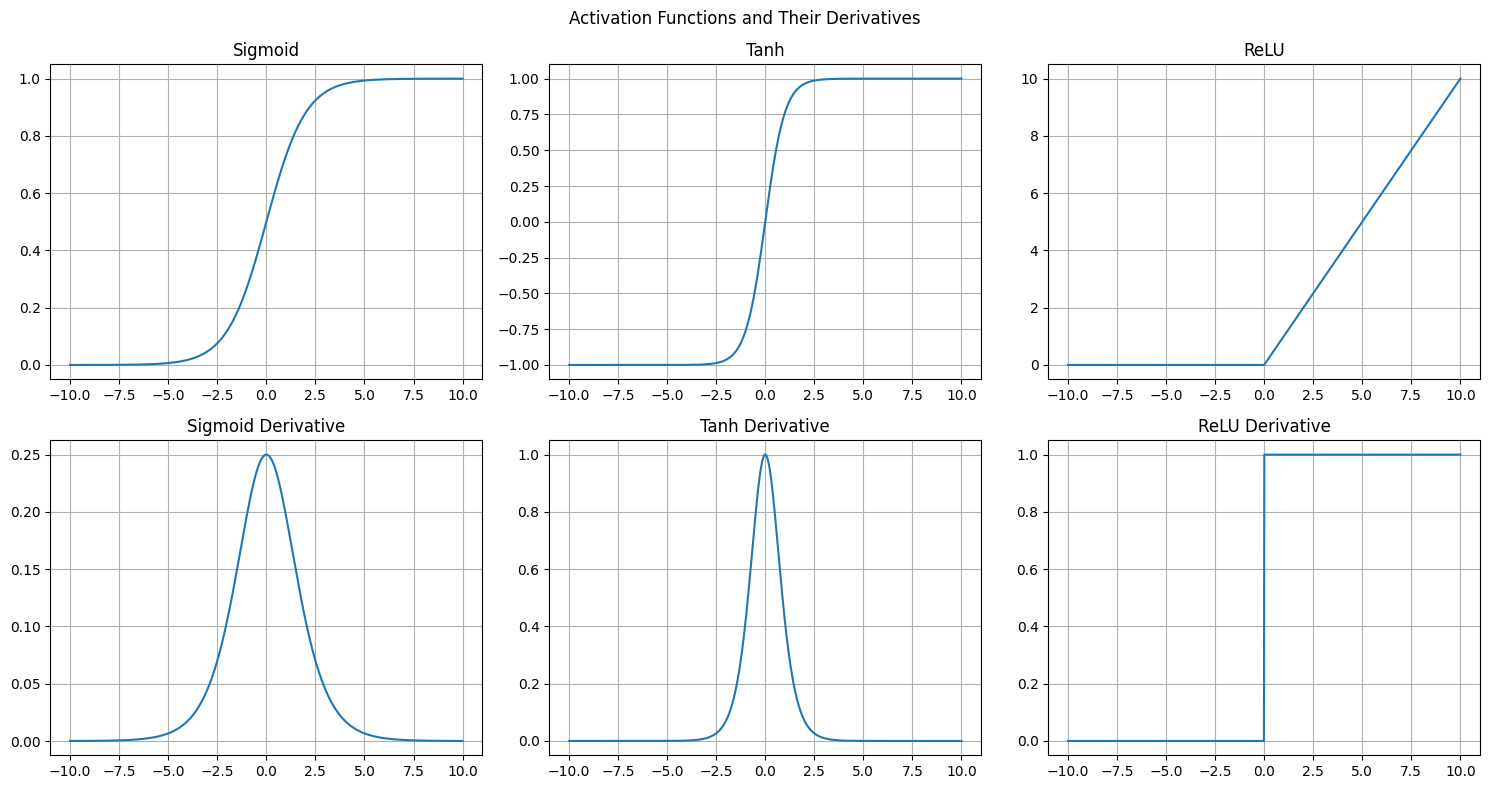

Sigmoid range: (0, 1)
Tanh range: (-1, 1)
ReLU range: [0, inf)


In [4]:
print("Abhishek J - 24BAD002")

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

x = np.linspace(-10, 10, 1000)

functions = [
    ("Sigmoid", sigmoid(x)),
    ("Tanh", tanh(x)),
    ("ReLU", relu(x)),
]
derivatives = [
    ("Sigmoid Derivative", sigmoid_derivative(x)),
    ("Tanh Derivative", tanh_derivative(x)),
    ("ReLU Derivative", relu_derivative(x)),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Activation Functions and Their Derivatives")

for ax, (title, y_vals) in zip(axes[0], functions):
    ax.plot(x, y_vals)
    ax.set_title(title)
    ax.grid(True)

for ax, (title, y_vals) in zip(axes[1], derivatives):
    ax.plot(x, y_vals)
    ax.set_title(title)
    ax.grid(True)

plt.tight_layout()
plt.show()

print("Sigmoid range: (0, 1)")
print("Tanh range: (-1, 1)")
print("ReLU range: [0, inf)")

**Comparison:**

| Aspect | Sigmoid | Tanh | ReLU |
|---|---|---|---|
| Output range | (0, 1) | (-1, 1) | [0, ∞) |
| Saturation regions | Both tails (\|x\|>~5) | Both tails (\|x\|>~3) | Left side only (x<0) |
| Gradient behavior | Vanishes at both extremes, max gradient 0.25 at x=0 | Vanishes at both extremes, max gradient 1 at x=0 (steeper than sigmoid) | Constant gradient of 1 for x>0, exactly 0 for x<0 ("dying ReLU") |
| Computational efficiency | Slow (exponential) | Slow (exponential) | Very fast (simple thresholding) |
| Typical applications | Output layer of binary classifiers, gates in LSTMs | Hidden layers of shallow nets, RNN hidden states | Hidden layers of most modern deep networks (CNNs, MLPs) |

---

## PART B: Performance Comparison of Activation Functions


In [5]:
print("Abhishek J - 24BAD002")

def build_model(activation):
    model = keras.Sequential([
        keras.layers.Input(shape=(64,)),
        keras.layers.Dense(64, activation=activation),
        keras.layers.Dense(32, activation=activation),
        keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

activation_list = ['sigmoid', 'tanh', 'relu']
histories_act = {}
results_act = {}

for act in activation_list:
    print(f"Training with {act} activation")
    model = build_model(act)
    history = model.fit(X_train, y_train,
                         validation_data=(X_test, y_test),
                         epochs=40, batch_size=32, verbose=0)
    histories_act[act] = history.history
    results_act[act] = {
        'train_acc': history.history['accuracy'][-1],
        'val_acc': history.history['val_accuracy'][-1],
        'train_loss': history.history['loss'][-1],
        'val_loss': history.history['val_loss'][-1],
    }
    print(f"{act}: val_acc={results_act[act]['val_acc']:.4f}, val_loss={results_act[act]['val_loss']:.4f}")

Abhishek J - 24BAD002
Training with sigmoid activation
sigmoid: val_acc=0.9722, val_loss=0.1478
Training with tanh activation
tanh: val_acc=0.9806, val_loss=0.0961
Training with relu activation
relu: val_acc=0.9778, val_loss=0.1040


Abhishek J - 24BAD002


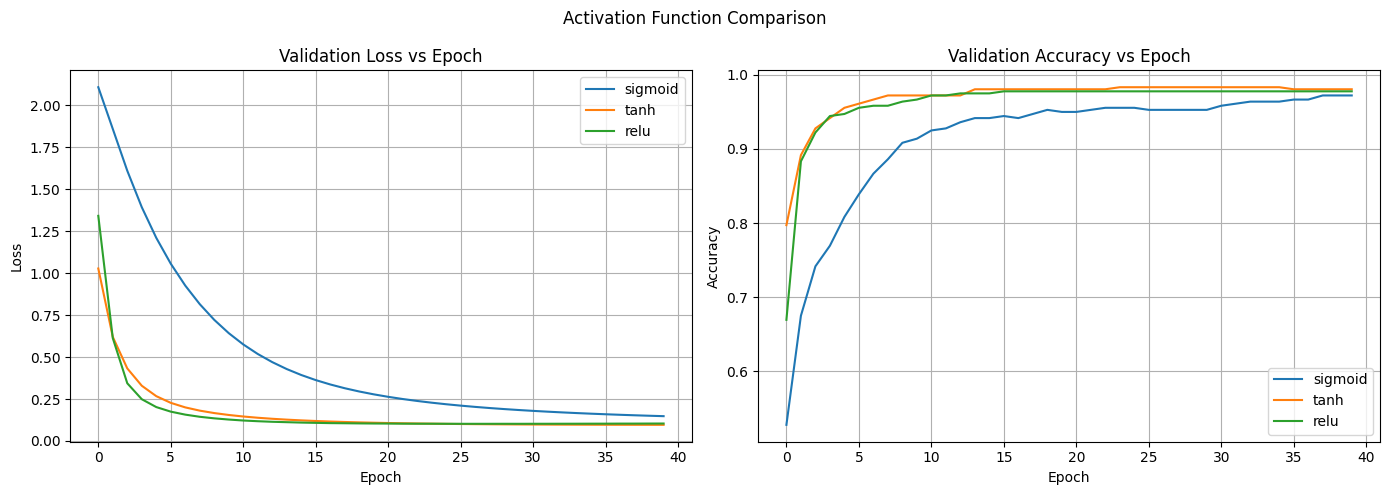

Summary:
sigmoid: train_acc=0.9937, val_acc=0.9722, train_loss=0.0680, val_loss=0.1478
tanh: train_acc=1.0000, val_acc=0.9806, train_loss=0.0070, val_loss=0.0961
relu: train_acc=1.0000, val_acc=0.9778, train_loss=0.0020, val_loss=0.1040


In [6]:
print("Abhishek J - 24BAD002")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Activation Function Comparison")

for act in activation_list:
    axes[0].plot(histories_act[act]['val_loss'], label=act)
    axes[1].plot(histories_act[act]['val_accuracy'], label=act)

axes[0].set_title("Validation Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Validation Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Summary:")
for act in activation_list:
    r = results_act[act]
    print(f"{act}: train_acc={r['train_acc']:.4f}, val_acc={r['val_acc']:.4f}, "
          f"train_loss={r['train_loss']:.4f}, val_loss={r['val_loss']:.4f}")

## PART C: Comparison of Optimization Algorithms


In [7]:
print("Abhishek J - 24BAD002")

def build_relu_model():
    return keras.Sequential([
        keras.layers.Input(shape=(64,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

optimizers = {
    'SGD': keras.optimizers.SGD(learning_rate=0.01),
    'Momentum': keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSProp': keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': keras.optimizers.Adam(learning_rate=0.001),
}

histories_opt = {}
results_opt = {}

for name, opt in optimizers.items():
    print(f"Training with {name} optimizer")
    model = build_relu_model()
    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    history = model.fit(X_train, y_train,
                         validation_data=(X_test, y_test),
                         epochs=40, batch_size=32, verbose=0)
    histories_opt[name] = history.history
    results_opt[name] = {
        'train_acc': history.history['accuracy'][-1],
        'val_acc': history.history['val_accuracy'][-1],
        'train_loss': history.history['loss'][-1],
        'val_loss': history.history['val_loss'][-1],
    }
    print(f"{name}: val_acc={results_opt[name]['val_acc']:.4f}, val_loss={results_opt[name]['val_loss']:.4f}")

Abhishek J - 24BAD002
Training with SGD optimizer
SGD: val_acc=0.9611, val_loss=0.1394
Training with Momentum optimizer
Momentum: val_acc=0.9833, val_loss=0.0763
Training with RMSProp optimizer
RMSProp: val_acc=0.9833, val_loss=0.1296
Training with Adam optimizer
Adam: val_acc=0.9750, val_loss=0.1303


Abhishek J - 24BAD002


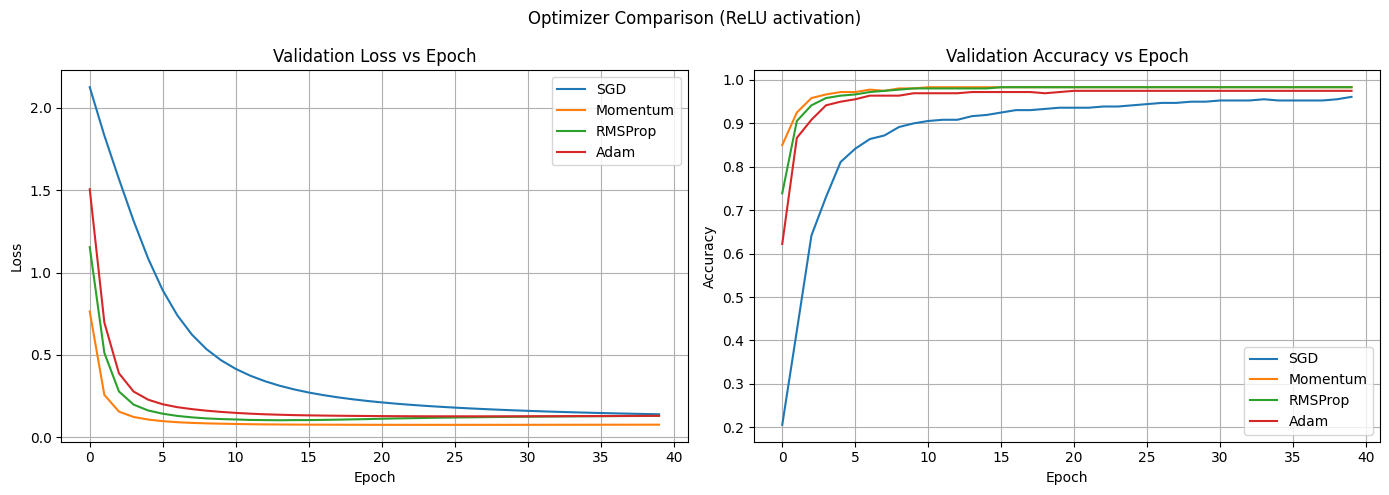

Summary:
SGD: train_acc=0.9868, val_acc=0.9611, train_loss=0.0798, val_loss=0.1394
Momentum: train_acc=1.0000, val_acc=0.9833, train_loss=0.0027, val_loss=0.0763
RMSProp: train_acc=1.0000, val_acc=0.9833, train_loss=0.0001, val_loss=0.1296
Adam: train_acc=1.0000, val_acc=0.9750, train_loss=0.0019, val_loss=0.1303


In [8]:
print("Abhishek J - 24BAD002")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optimizer Comparison (ReLU activation)")

for name in optimizers:
    axes[0].plot(histories_opt[name]['val_loss'], label=name)
    axes[1].plot(histories_opt[name]['val_accuracy'], label=name)

axes[0].set_title("Validation Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Validation Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Summary:")
for name in optimizers:
    r = results_opt[name]
    print(f"{name}: train_acc={r['train_acc']:.4f}, val_acc={r['val_acc']:.4f}, "
          f"train_loss={r['train_loss']:.4f}, val_loss={r['val_loss']:.4f}")

## PART D: Deep Learning Experiment Management


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import os
save_dir = '/content/drive/MyDrive/DL_Lab/Expt2_24BAD002'
os.makedirs(save_dir, exist_ok=True)
model.save(f'{save_dir}/best_model.keras')